In [1]:
import numpy as np
import matplotlib.pyplot as plt
import maglab
import torch
import torch.nn.functional as F
import pandas as pd
import os
from scipy.ndimage import gaussian_filter, map_coordinates
from pyevtk.hl import gridToVTK
import h5py

In [2]:
l = 16
file_path = f'/home/zhaoy/studio/target-skyrmion/zheng_pmdata/zfs_refin_pm/3dmi_loss/{l:g}_layers_loss/results/loss{l:.1e}_wphi1.0e+07'
#file_path = f'D:\\Projects\\TargetSkyrmion\\targetdata\\1test_phi\\results\\loss{l:.1e}_wphi1.0e+07'

In [3]:
def segment_spin_data(spin_tensor: torch.Tensor, smoothing_sigma: float = 2.0):
    if not isinstance(spin_tensor, torch.Tensor):
        raise TypeError("The input data must be PyTorch tensor!")

    if spin_tensor.dim() != 4 or spin_tensor.shape[0] != 3:
        raise ValueError(f"The tensor's shape must be (3, nx, ny, nz), but received {spin_tensor.shape}")

    spin = spin_tensor.cpu().numpy()
    _, nx, ny, nz = spin.shape
    cx, cy = (nx - 1) / 2.0, (ny - 1) / 2.0
    print(f"data parameter: nx={nx}, ny={ny}, nz={nz}")
    
    num_angles = 360
    max_radius = int(min(cx, cy)) + 1
    midpoint_radii = np.full((nz, num_angles), np.nan)

    for k in range(nz):
        mz_slice = spin[2, :, :, k]
        for i in range(num_angles):
            angle = 2 * np.pi * i / num_angles
            cos_a, sin_a = np.cos(angle), np.sin(angle)        
            zero_crossings_r = []
            mz_prev = mz_slice[int(round(cx)), int(round(cy))] 
            for r in range(1, max_radius):
                x_pos, y_pos = cx + r * cos_a, cy + r * sin_a
                if not (0 <= x_pos < nx and 0 <= y_pos < ny):
                    break
                
                ix, iy = int(round(x_pos)), int(round(y_pos))
                mz_current = mz_slice[ix, iy]
                
                if np.sign(mz_current) != np.sign(mz_prev):
                    zero_crossings_r.append(r)
                    if len(zero_crossings_r) == 2:
                        break
                mz_prev = mz_current

            if len(zero_crossings_r) >= 2:
                midpoint_radii[k, i] = (zero_crossings_r[0] + zero_crossings_r[1]) / 2.0
            elif k > 0:
                midpoint_radii[k, i] = midpoint_radii[k-1, i]

    if np.isnan(midpoint_radii[0, :]).any():
        mean_radius_z0 = np.nanmean(midpoint_radii[0, :])
        midpoint_radii[0, np.isnan(midpoint_radii[0, :])] = mean_radius_z0

    for k in range(1, nz):
        if np.isnan(midpoint_radii[k, :]).any():
            nan_indices = np.isnan(midpoint_radii[k, :])
            midpoint_radii[k, nan_indices] = midpoint_radii[k-1, nan_indices]

    if smoothing_sigma > 0:
        smooth_midpoint_radii = gaussian_filter(midpoint_radii, sigma=smoothing_sigma, mode='wrap')
    else:
        smooth_midpoint_radii = midpoint_radii 
    
    spin_skyrmion_np = np.zeros_like(spin)
    spin_edge_np = np.zeros_like(spin)

    ii, jj = np.mgrid[0:nx, 0:ny]
    distance_from_center = np.sqrt((ii - cx)**2 + (jj - cy)**2)
    angle_from_center = np.arctan2(jj - cy, ii - cx)
    angle_indices = np.round((angle_from_center + np.pi) / (2 * np.pi) * (num_angles - 1)).astype(int)
    angle_indices = np.clip(angle_indices, 0, num_angles-1) 

    for k in range(nz):
        boundary_radii_slice = smooth_midpoint_radii[k, angle_indices]
        inner_mask_2d = distance_from_center < boundary_radii_slice

        spin_slice_k = spin[:, :, :, k]
        
        spin_skyrmion_np[:, :, :, k] = np.where(inner_mask_2d, spin_slice_k, 0)
        spin_edge_np[:, :, :, k] = np.where(~inner_mask_2d, spin_slice_k, 0)

    spin_skyrmion_tensor = torch.from_numpy(spin_skyrmion_np).to(spin_tensor.dtype).to(spin_tensor.device)
    spin_edge_tensor = torch.from_numpy(spin_edge_np).to(spin_tensor.dtype).to(spin_tensor.device)
    return spin_skyrmion_tensor, spin_edge_tensor

def get_spin(file_path="path_file"):
    file_path = file_path
    dx = 1.06e-9
    geo = maglab.geo.cylider(136, 111)
    nx, ny, nz = geo.shape
    micro = maglab.Micro(nx, ny, nz, dx)
    state = micro.load_state(f"{file_path}/final.pth")
    spin = state.spin
    spin_skyrmion, spin_edge = segment_spin_data(spin.detach().cpu())
    return spin, spin_skyrmion, spin_edge, nz

def apply_filter(phase):
    phase1 = F.conv2d(phase.unsqueeze(0), kernel.repeat(1, 1, 1, 1).cuda(), groups=1, padding=gauss_kernel_size // 2)[0,]
    return (phase-phase1).data.cuda()

def create_skyrmion_mask_and_vtk(spin_tensor: torch.Tensor, 
                                 target_mz: float = 0.0, 
                                 smoothing_sigma: float = 2.0,
                                 R_conf: float = None, 
                                 output_filename: str = None):
    """
    According to the target_mz isovalue surface, segment a 3D spin data tensor, and before generating Mask and VTK,
    rotate the obtained distance field (distance_field_np) by 180 degrees in the XY plane center.

    R_conf: limit the calculation radius for each ray.
    target_mz: the mz isovalue for segmentation.
    """
    if not isinstance(spin_tensor, torch.Tensor):
        raise TypeError("The input data must be PyTorch tensor!")

    if spin_tensor.dim() != 4 or spin_tensor.shape[0] != 3:
        raise ValueError(f"The tensor's shape must be (3, nx, ny, nz), but received {spin_tensor.shape}")
    
    spin = spin_tensor.cpu().numpy()
    _, nx, ny, nz = spin.shape
    cx, cy = (nx - 1) / 2.0, (ny - 1) / 2.0

    if R_conf is None:
        R_conf = min(cx, cy) 
    
    num_angles = 720
    boundary_radii = np.full((nz, num_angles), np.nan)

    def find_boundary_radius_for_slice(k):
        mz_slice = spin[2, :, :, k]
        radii_k = np.full(num_angles, np.nan)

        max_r_step = int(np.ceil(R_conf))   # the maximum number of steps along the ray
        
        for i in range(num_angles):
            angle = 2 * np.pi * i / num_angles
            cos_a, sin_a = np.cos(angle), np.sin(angle)
            
            zero_crossings_r = []
            mz_prev = mz_slice[int(round(cx)), int(round(cy))]

            for r in range(1, max_r_step + 1): 
                x_pos, y_pos = cx + r * cos_a, cy + r * sin_a

                ix, iy = int(round(x_pos)), int(round(y_pos))
                if not (0 <= ix < nx and 0 <= iy < ny):
                    break
                
                mz_current = mz_slice[ix, iy]

                if np.sign(mz_current - target_mz) != np.sign(mz_prev - target_mz):
                    if (mz_current - mz_prev) != 0: 
                        r_exact = r - 1 + abs(target_mz - mz_prev) / abs(mz_current - mz_prev)
                        if r_exact <= R_conf:
                            zero_crossings_r.append(r_exact)
                            if len(zero_crossings_r) == 2:
                                break
                mz_prev = mz_current

            if len(zero_crossings_r) >= 2:
                radii_k[i] = (zero_crossings_r[0] + zero_crossings_r[1]) / 2.0
        
        return radii_k

    def fill_intra_slice_nans(radii_arr):
        nan_indices = np.isnan(radii_arr)
        if np.any(nan_indices):
            if np.all(nan_indices):
                radii_arr[:] = 0.0
            else:
                mean_val = np.nanmean(radii_arr)
                radii_arr[nan_indices] = mean_val
        return radii_arr

    mid_z = nz // 2 # from middle slice to both ends
    print(f"Processing center slice: {mid_z}")
    center_radii = find_boundary_radius_for_slice(mid_z)
    boundary_radii[mid_z, :] = fill_intra_slice_nans(center_radii)

    # (mid_z + 1 -> nz - 1)
    for k in range(mid_z + 1, nz):
        current_radii = find_boundary_radius_for_slice(k)
        prev_radii = boundary_radii[k-1, :]
        boundary_radii[k, :] = np.where(np.isnan(current_radii), prev_radii, current_radii)

    # (mid_z - 1 -> 0)
    for k in range(mid_z - 1, -1, -1):
        current_radii = find_boundary_radius_for_slice(k)
        prev_radii = boundary_radii[k+1, :]
        boundary_radii[k, :] = np.where(np.isnan(current_radii), prev_radii, current_radii)

    if smoothing_sigma > 0:
        smooth_boundary_radii = gaussian_filter(boundary_radii, sigma=smoothing_sigma, mode='nearest')
    else:
        smooth_boundary_radii = boundary_radii

    ii, jj = np.mgrid[0:nx, 0:ny]
    distance_from_center = np.sqrt((ii - cx)**2 + (jj - cy)**2)
    angle_from_center = np.arctan2(jj - cy, ii - cx)
    
    angle_indices = np.round((angle_from_center + np.pi) / (2 * np.pi) * (num_angles - 1)).astype(int)
    angle_indices = np.clip(angle_indices, 0, num_angles - 1)

    distance_field_np = np.zeros((nx, ny, nz), dtype=np.float32)

    for k in range(nz):
        boundary_radii_slice = smooth_boundary_radii[k, angle_indices]
        distance_field_np[:, :, k] = distance_from_center - boundary_radii_slice
    
    distance_field_np = gaussian_filter(distance_field_np, sigma=1.5)
    
    # rotate the distance field by 180 degrees around Z axis
    rotated_distance_field_np = np.rot90(distance_field_np, k=2, axes=(0, 1))
    inner_mask_3d = rotated_distance_field_np < 0.0

    # output VTK file if filename is provided
    if output_filename:
            grid_spacing = 1.06e-9 
            origin_x = -(nx - 1) / 2.0 * grid_spacing
            origin_y = -(ny - 1) / 2.0 * grid_spacing
            origin_z = -(nz - 1) / 2.0 * grid_spacing

            x = np.linspace(origin_x, origin_x + (nx-1)*grid_spacing, nx)
            y = np.linspace(origin_y, origin_y + (ny-1)*grid_spacing, ny)
            z = np.linspace(origin_z, origin_z + (nz-1)*grid_spacing, nz)

            rotated_distance_field_fortran = np.asfortranarray(rotated_distance_field_np)
            gridToVTK(output_filename, x, y, z, pointData={'distance_field': rotated_distance_field_fortran})        
    return inner_mask_3d

In [4]:
N = 206
dx = 1.06e-9
Ms = 3.84e5
angles = [0, -28, -44, -50, -54, -58, -61, -65]
geo = maglab.geo.cylider(136, 111)
nx, ny, nz = geo.shape
micro = maglab.Micro(nx, ny, nz, dx)
phasemapper = maglab.PhaseMapper(N, dx, rotation_padding=N).cuda()

gauss_kernel_size = 99
sigma = maglab.preprocess.compute_sigma(gauss_kernel_size)
kernel = maglab.preprocess.gaussian_kernel(gauss_kernel_size, sigma)
kernel_groups = kernel.repeat(8, 1, 1, 1).cuda()
print(f"Sigma: {sigma}")

Sigma: 15.2


In [5]:
spin, spin_skyrmion, spin_edge, nz = get_spin(file_path)
mask_inner = create_skyrmion_mask_and_vtk(
    spin_tensor=spin.detach().cpu(),
    target_mz=-0.9,
    smoothing_sigma=3.0,
    R_conf=50,
    output_filename=None
)

mask_inner = torch.from_numpy(mask_inner).to(spin.device)
spin_skyrmion = (spin * mask_inner) 
mask_outer = ~mask_inner
spin_edge = (spin * mask_outer)

dirs = {
    'orig': 'hdf5/original',
    'skyr':  'hdf5/skyr',
    'edge':  'hdf5/edge'
}
for d in dirs.values(): os.makedirs(d, exist_ok=True)

for angle in angles:
    alpha = angle
    abs_ang = np.abs(angle)
    
    phi_orig = apply_filter(phasemapper(spin, alpha=alpha, Ms=Ms))
    phi_skyr  = apply_filter(phasemapper(spin * mask_inner, alpha=alpha, Ms=Ms))
    phi_edge  = apply_filter(phasemapper(spin * mask_outer, alpha=alpha, Ms=Ms))
    
    results = [
        (phi_orig, dirs['orig']),
        (phi_skyr,  dirs['skyr']),
        (phi_edge,  dirs['edge'])
    ]
    
    for data, folder in results:
        save_path = os.path.join(folder, f'phase_{abs_ang:g}.hdf5')
        with h5py.File(save_path, 'w') as hf:
            hf.create_dataset('phase', data=data.detach().cpu().numpy().astype(np.float32))
            
    print(f"Finished Angle: {abs_ang}")

print("\nAll processing completed!")

/home/zhaoy/anaconda3/envs/tomopy/lib/python3.12/site-packages/maglab-0.1-py3.12.egg/maglab/micro.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


data parameter: nx=136, ny=136, nz=111
Processing center slice: 55
Finished Angle: 0
Finished Angle: 28
Finished Angle: 44
Finished Angle: 50
Finished Angle: 54
Finished Angle: 58
Finished Angle: 61
Finished Angle: 65

All processing completed!


Pyramid plotting phase image

Python 3.5.6 |Anaconda, Inc.| (default, Jun  4 2021, 13:57:47) 
[GCC 7.5.0] on linux


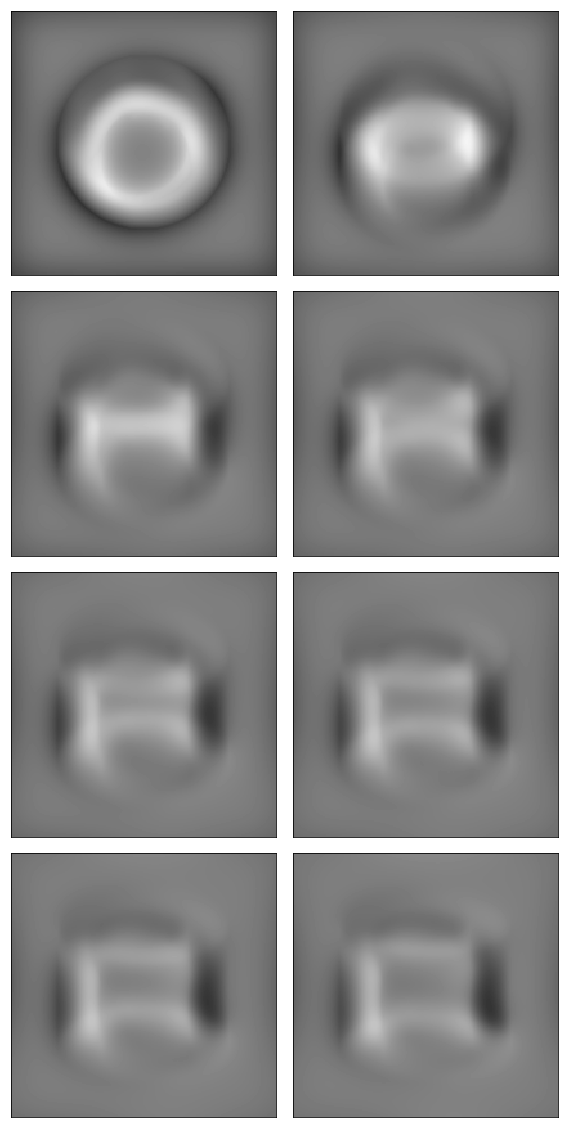

In [13]:
import sys
sys.path.extend(['/home/zhaoy/packages/Pyramid']) 
#sys.path.extend(['/Users/fzheng/SkyDrive/Codes/Python/Pyramid']) # where Pyramid situates
print('Python %s on %s' % (sys.version, sys.platform))

import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline
import pyramid as pr
from scipy.ndimage import rotate, gaussian_filter
pr.plottools.pretty_plots()
import h5py

# angles = [0, 5.2, 8.2, 12.2, 16, 20, 24, 28, 32, 36, 40.8, 44, 46.9, 50, 54, 58, 61, 65.2]
angles = [0, 28, 44, 50, 54, 58, 61, 65]
fig = plt.figure(figsize=(8, 16))
ax = {}
for i, angle in enumerate(angles):
    phase_name = './hdf5/edge/phase_{:g}.hdf5'.format(angle)
    with h5py.File(phase_name, 'r') as hf:
        phase = np.fliplr(rotate(hf['phase'][:], angle=90, reshape=False, order=1))
        phase = pr.PhaseMap(a=1, phase=phase)
        phase.phase = gaussian_filter(phase.phase, sigma=0) 
    tilt = angle
    ax[i+1] = fig.add_subplot(4, 2, i+1, aspect='equal')
    ax[i+1].get_xaxis().set_visible(False)
    ax[i+1].get_yaxis().set_visible(False)
    #phase.plot_holo(axis=ax[i+1],gain=60,scalebar=False,colorwheel=False,note="{}".format(''))
    phase.plot_phase(axis=ax[i+1],scalebar=False,note="{}".format(''),cbar=False,show_mask=True,cmap='gray',vmax=0.5,vmin=-0.5)
    plt.tight_layout(h_pad=0.4)